# Hybrid A* — plan once

Debug notebook: call the pybind `hybrid_astar` module, plan once, and visualize the **rear-axle** trajectory .

Build first:
```bash
cd build && cmake .. && make -j
```
Module output: `build/python/hybrid_astar*.so`


In [ ]:
import sys
from pathlib import Path
import math

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "build").exists() and (ROOT.parent / "build").exists():
  ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "python"))
sys.path.insert(0, str(ROOT / "build" / "python"))
sys.path.insert(0, str(ROOT / "build"))

import hybrid_astar

print("vehicle L/W/R =", hybrid_astar.vehicle_length, hybrid_astar.vehicle_width, hybrid_astar.min_turning_radius)
print("res xy/phi/dij =", hybrid_astar.xy_grid_resolution, hybrid_astar.phi_grid_resolution, hybrid_astar.grid_dijkstra_xy_resolution)
print("headings =", hybrid_astar.headings)
print("module:", hybrid_astar.__file__)


In [ ]:
def pose_to_box(x, y, theta, length, width, center_to_geometry_center, **kwargs):
  """Vehicle rectangle from rear-axle pose (x, y, theta) in meters."""
  c, s = np.cos(theta), np.sin(theta)
  cx = x + center_to_geometry_center * c
  cy = y + center_to_geometry_center * s
  corners = np.array([
    [ length / 2, width / 2],
    [-length / 2, width / 2],
    [-length / 2, -width / 2],
    [ length / 2, -width / 2],
  ])
  rot = np.array([[c, -s], [s, c]])
  world = corners @ rot.T + np.array([cx, cy])
  return patches.Polygon(world, closed=True, **kwargs)


def plot_path(ax, path, color, label, length, width, d_cg, draw_cars=True):
  pts = np.asarray(path, dtype=float)
  if pts.size == 0:
    print(f"{label}: empty path")
    return
  ax.plot(pts[:, 0], pts[:, 1], "-o", color=color, ms=3, label=label)
  if draw_cars:
    for x, y, t in pts[:: max(1, len(pts) // 8)]:
      ax.add_patch(pose_to_box(
        x, y, t, length, width, d_cg,
        fill=False, edgecolor=color, linewidth=0.8, alpha=0.5))


def plan_once(start, goal, width_m=20, height_m=20, occupancy=None,
              obstacle_lines=None, init_v=0.5, visualize=True, save_path=None):
  """Plan with poses in meters; width_m/height_m are map extents in meters."""
  xy = float(hybrid_astar.xy_grid_resolution)
  width = max(1, int(math.ceil(width_m / xy)))
  height = max(1, int(math.ceil(height_m / xy)))

  planner = hybrid_astar.Planner()
  result = planner.plan(
    start_x=float(start[0]), start_y=float(start[1]), start_t=float(start[2]),
    goal_x=float(goal[0]), goal_y=float(goal[1]), goal_t=float(goal[2]),
    width=width, height=height,
    occupancy=occupancy,
    obstacle_lines=obstacle_lines,
    init_v=float(init_v),
  )
  print(f"SbpResult: status={result.status}, iteration_times={result.iteration_times}, computation_duration={result.computation_duration:.2f} ms, {result.debug_string}")

  if not visualize:
    print(f"path points: {len(result.path)}, iteration_times={result.iteration_times}")
    return result

  L = hybrid_astar.vehicle_length
  W = hybrid_astar.vehicle_width
  d_cg = hybrid_astar.center_to_geometry_center

  fig, ax = plt.subplots(figsize=(8, 8))
  if occupancy is not None:
    ax.imshow(occupancy, origin="lower", cmap="Greys", alpha=0.4,
         extent=[0, width_m, 0, height_m])

  if obstacle_lines:
    for i, line in enumerate(obstacle_lines):
      if len(line) == 2:
        xs = [line[0][0], line[1][0]]
        ys = [line[0][1], line[1][1]]
      else:
        xs = [line[0], line[2]]
        ys = [line[1], line[3]]
      ax.plot(xs, ys, "r-", lw=1.2, alpha=0.85,
          label="obstacle_lines" if i == 0 else None)

  plot_path(ax, result.path, "C0", "path", L, W, d_cg)

  ax.add_patch(pose_to_box(*start, L, W, d_cg, fill=False, edgecolor="blue", linewidth=2, label="start"))
  ax.add_patch(pose_to_box(*goal, L, W, d_cg, fill=False, edgecolor="green", linewidth=2, label="goal"))
  ax.plot(start[0], start[1], "b+", ms=12)
  ax.plot(goal[0], goal[1], "g+", ms=12)

  ax.set_aspect("equal")
  ax.set_xlim(0, width_m)
  ax.set_ylim(0, height_m)
  ax.grid(True, alpha=0.3)
  ax.legend(loc="best")
  ax.set_title(f"Hybrid A* xy={xy} init_v={init_v}")
  if save_path:
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
  plt.show()

  print(f"grid cells: {width}x{height}, path points: {len(result.path)}, iteration_times={result.iteration_times}")
  return result


## Case 1 — free space straight-ish

SbpResult: status=SbpStatus.SUCCESS, iteration_times=27, computation_duration=34.91 ms, iteration_times = 27, computation_duration = 34.912114 ms


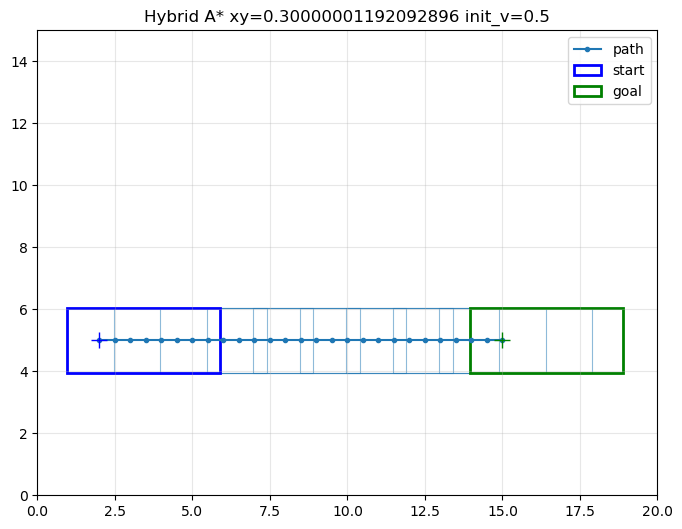

grid cells: 67x50, path points: 27, iteration_times=27


In [3]:
start = (2.0, 5.0, 0.0)
goal = (15.0, 5.0, 0.0)
result = plan_once(start, goal, width_m=20, height_m=15)


## Case 2 — change heading (parallel park style pose change)

In [ ]:
start = (3.0, 12.0, np.pi)
goal = (12.0, 4.0, np.deg2rad(90))
result = plan_once(start, goal, width_m=20, height_m=15, init_v=-0.5,
                   save_path=str(ROOT / "backward_demo.jpg"))


## Case 3 — heading change with larger map

Collision uses geometric `obstacle_lines` (pass via `plan_once(..., obstacle_lines=...)`).
Occupancy grid / `setMap` is still unused.


SbpResult: status=SbpStatus.SUCCESS, iteration_times=1, computation_duration=49.83 ms, iteration_times = 1, computation_duration = 49.831736 ms


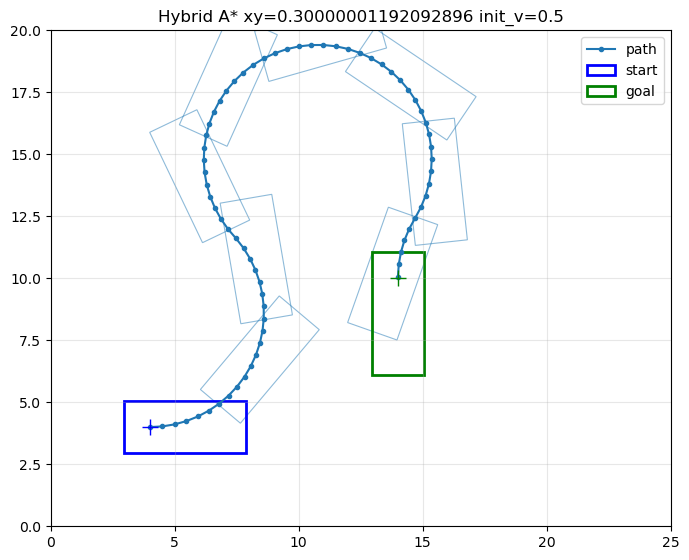

grid cells: 84x67, path points: 68, iteration_times=1
last pose: [14.000396728515625, 10.060391426086426, 4.699248313903809]


In [5]:
start = (4.0, 4.0, np.deg2rad(0))
goal = (14.0, 10.0, np.deg2rad(-90))
result = plan_once(start, goal, width_m=25, height_m=20)
print("last pose:", result.path[-1] if result.path else None)
